In [1]:
!pip install langchain langchain_core langchain_community langgraph langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.4/262.4 kB 21.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai

In [2]:
pip install -U google-generativeai

In [27]:
from google.colab import userdata
import os
os.environ['GEMINI_API_KEY']=userdata.get('MY_GEMINI_KEY')
#print(os.environ['GEMINI_API_KEY'])

In [4]:
from google.colab import userdata
import os
import google.generativeai as genai

# Get your API key from Google AI Studio and store it in Colab secrets as 'GOOGLE_API_KEY'
GOOGLE_API_KEY = userdata.get('MY_GEMINI_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

# Verify if the API key is set
if not GOOGLE_API_KEY:
    raise ValueError("GOOGLE_API_KEY not found in Colab secrets. Please add it.")

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [5]:
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [6]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the Gemini model
llm_gemini = ChatGoogleGenerativeAI(model="gemini-2.5-flash",temperature=0)

# Test the Gemini model
response_gemini = llm_gemini.invoke("What is the capital of Switzerland?")
print(response_gemini)
print(response_gemini.content,"\n",response_gemini.usage_metadata['total_tokens'])

content='The capital of Switzerland is **Bern**.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a0cd59-312b-76b3-b3a9-0bd3eca964f0-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 8, 'output_tokens': 23, 'total_tokens': 31, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 15}}
The capital of Switzerland is **Bern**. 
 31


In [28]:
from typing_extensions import TypedDict

class State(TypedDict):
  application: str
  exp_level: str
  skill_match: str
  response:str

In [29]:
from langgraph.graph import StateGraph, START, END
from langchain_core.prompts import ChatPromptTemplate

workflow=StateGraph(State)

In [30]:
def categorize_experience(state:State)-> State:
  print("\n Categorizing the candidates: ")
  prompt=ChatPromptTemplate.from_template(
      "Based on the candidate's application, categorize their experience level. "
      "Respond with exactly one of these labels: 'Entry-level', 'Mid-level', or 'Senior-level'. "
      "Do not include any extra text, explanation, or formatting.\n\n"
      "Application: {application}"
  )
  chain=prompt|llm_gemini
  state['exp_level']=chain.invoke(state).content.strip()
  return state

def assess_skills(state:State)-> State:
  print("\n Assessing the candidates skills: ")
  prompt=ChatPromptTemplate.from_template(
      "Assess the candidate's skills for a Python Developer job application. "
      "Respond with exactly one of these labels: 'Match', 'Outstanding', or 'No Match'. "
      "Do not include any extra text, explanation, or formatting.\n\n"
      "Application: {application}"
  )
  chain=prompt|llm_gemini
  state['skill_match']=chain.invoke(state).content.strip()
  return state

def schedule_hr_interview(state:State) -> State:
  print("\n Scheduling the HR interview: ")
  return {"response": "HR interview for the candidate has been scheduled."}

def schedule_client_interview(state:State) -> State:
  print("\n Scheduling the client interview: ")
  return {"response": "Client interview for the candidate has been scheduled as the profile is Outstanding."}

def esclate_to_recruiter(state:State) -> State:
  print("\n Escalating the candidate to the recruiter: ")
  return {"response": "Candidate has been escalated to the recruiter for review due to no skill match, but higher experience."}

def reject_application(state:State) -> State:
  print("\n Rejecting the candidate application: ")
  return {"response": "Candidate application has been rejected due to skill mismatch."}

In [31]:
workflow.add_node("categorize_experience", categorize_experience)
workflow.add_node("assess_skills", assess_skills)
workflow.add_node("schedule_hr_interview", schedule_hr_interview)
workflow.add_node("schedule_client_interview", schedule_client_interview)
workflow.add_node("esclate_to_recruiter", esclate_to_recruiter)
workflow.add_node("reject_application", reject_application)

In [32]:
def route_app(state:State) -> str:
  if state['skill_match'] == 'Match':
    return "schedule_hr_interview"
  elif state['exp_level']=='Mid-level' and state['skill_match'] == 'Outstanding':
       return "schedule_client_interview"
  elif state['exp_level'] == 'Senior-level':
    return "esclate_to_recruiter"
  else:
    return "reject_application"


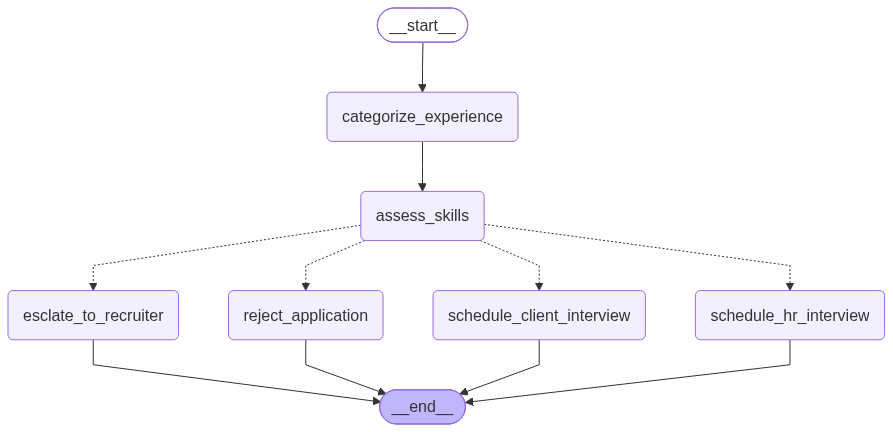

In [33]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")

In [34]:
def run_candidate_screening(application: str):
  results = app.invoke({"application" : application})
  return {
      "exp_level" : results["exp_level"],
      "skill_match" : results["skill_match"],
      "response" : results["response"]
  }

In [36]:
# 1. Initialize StateGraph
workflow = StateGraph(State)

# 2. Add all defined nodes
workflow.add_node("categorize_experience", categorize_experience)
workflow.add_node("assess_skills", assess_skills)
workflow.add_node("schedule_hr_interview", schedule_hr_interview)
workflow.add_node("schedule_client_interview", schedule_client_interview)
workflow.add_node("esclate_to_recruiter", esclate_to_recruiter)
workflow.add_node("reject_application", reject_application)

# 3. Add direct entrypoint and transition edges
workflow.add_edge(START, "categorize_experience")
workflow.add_edge("categorize_experience", "assess_skills")

# 4. Add conditional routing edges from assess_skills to target nodes
workflow.add_conditional_edges(
    "assess_skills",
    route_app,
    {
        "schedule_hr_interview": "schedule_hr_interview",
        "schedule_client_interview": "schedule_client_interview",
        "esclate_to_recruiter": "esclate_to_recruiter",
        "reject_application": "reject_application"
    }
)

# 5. Connect processing end-points to END
workflow.add_edge("schedule_hr_interview", END)
workflow.add_edge("schedule_client_interview", END)
workflow.add_edge("esclate_to_recruiter", END)
workflow.add_edge("reject_application", END)

# 6. Compile the application cleanly
app = workflow.compile()

In [37]:
application_text = "I have 10 years of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['exp_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Final Decision: {results['response']}")


 Categorizing the candidates: 

 Assessing the candidates skills: 

 Escalating the candidate to the recruiter: 


Computed Results :
Application: I have 10 years of experience in software engineering with expertise in JAVA
Experience Level: Senior-level
Skill Match: No Match
Final Decision: Candidate has been escalated to the recruiter for review due to no skill match, but higher experience.


In [25]:
application_text = "I have 2 years of experience and expertise in Python"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['exp_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Final Decision: {results['response']}")


 Categorizing the candidates: 

 Assessing the candidates skills: 

 Scheduling the HR interview: 


Computed Results :
Application: I have 2 years of experience and expertise in Python
Experience Level: Entry-level
Skill Match: Match
Final Decision: HR interview for the candidate has been scheduled.


In [38]:
new_application_text = "I have 5 years of professional software engineering experience and I am an expert Python developer with extensive knowledge in LangGraph, PyTorch, and backend APIs."
new_results = run_candidate_screening(new_application_text)

print("\n\nComputed Results for New Case:")
print(f"Application: {new_application_text}")
print(f"Experience Level: {new_results['exp_level']}")
print(f"Skill Match: {new_results['skill_match']}")
print(f"Final Decision: {new_results['response']}")


 Categorizing the candidates: 

 Assessing the candidates skills: 

 Scheduling the client interview: 


Computed Results for New Case:
Application: I have 5 years of professional software engineering experience and I am an expert Python developer with extensive knowledge in LangGraph, PyTorch, and backend APIs.
Experience Level: Mid-level
Skill Match: Outstanding
Final Decision: Client interview for the candidate has been scheduled as the profile is Outstanding.
